# TOWRE Score Prediction — Transformer Approach
### Kaggle Notebook — 2×T4 GPU Optimised

**What changed vs. the original notebook**

| Change | Detail |
|---|---|
| `batch_size` 1 → **16** | 16× fewer DataLoader calls per epoch — biggest single win |
| **AMP** (FP16) | `autocast` + `GradScaler` — T4 tensor cores run FP16 ~2–3× faster |
| **DataParallel** | Both T4 GPUs used automatically when `N_GPUS > 1` |
| **Embedding cache** | All FastText lookups done **once** before training; `__getitem__` does zero FastText calls |
| **Row-selection augmentation** | Token dropout / RA-filler stripping via index slicing on cached matrices |
| `pin_memory=True` | Overlaps H2D PCIe transfer with CPU work |
| `num_workers=4` | Parallel prefetch workers for DataLoader |
| `non_blocking=True` | GPU transfers don't block Python thread |
| `set_to_none=True` | Frees gradient memory immediately (faster than zeroing) |
| `cudnn.benchmark=True` | Auto-selects fastest convolution kernels for fixed-ish input sizes |

**Quick-start**
1. Add `fasttext-english` dataset (cc.en.300.bin) to your Kaggle notebook inputs.
2. Fill in the two `# <-- FILL` paths in **Cell 1**.
3. Set accelerator to **2×T4 GPU** in notebook settings.
4. Run all cells top-to-bottom.
5. Predictions land in `/kaggle/working/outputs/`.


In [1]:
# Install extra dependencies (scikit-learn is pre-installed on Kaggle)
# !pip install -q fasttext-wheel   # pretrained FastText embeddings

import os, re, json, csv, math, time, random
from pathlib import Path
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast   # ★ AMP
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns

# ★ Multi-GPU detection
N_GPUS = torch.cuda.device_count()
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
for _i in range(N_GPUS):
    print(f"  GPU {_i}: {torch.cuda.get_device_name(_i)}")

# ★ Faster CUDA kernels for the fixed-ish sequence lengths in this task
torch.backends.cudnn.benchmark = True

# =============================================================================
#  PATHS  — fill in the two lines marked  # <-- FILL
# =============================================================================
CACHE_ROOT  = Path('/kaggle/input/datasets/suyashsachdeva/asr-kaggle-out/transcripts_cache')  # <-- FILL
SCORES_XLSX = Path('/kaggle/input/datasets/suyashsachdeva/asr-dataset/ASRdata_202502/timePoint1/t1_towre.xlsx')  # <-- FILL

OUTPUT_DIR     = Path('/kaggle/working/outputs')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
LOGS_DIR       = OUTPUT_DIR / 'logs'
for _d in [OUTPUT_DIR, CHECKPOINT_DIR, LOGS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ASR backbone names (all 4 are used as free data augmentation)
ASR_BACKBONES    = ['qwen-ASR-1.7B', 'groq__whisper-large-v3',
                    'groq__whisper-large-v3-turbo', 'sarvam__saaras-v3']
PRIMARY_BACKBONE = 'qwen-ASR-1.7B'
FOLDERS          = ['t1']

# 108 TOWRE words
TOWRE_WORDS = [
    'is','up','cat','red','me','to','no','we','he','the',
    'and','yes','of','him','as','book','was','help','then','time',
    'wood','let','men','baby','new','stop','work','jump','part','fast',
    'fine','milk','back','lost','find','paper','open','kind','able','shoes',
    'money','great','father','river','space','short','left','people','almost','waves',
    'child','strong','crowd','better','inside','plane','pretty','famous','children','without',
    'finally','strange','budget','repress','contain','justice','morning','resolve','describe','garment',
    'business','qualify','potent','collapse','elements','pioneer','remember','dangerous','uniform','necessary',
    'problems','absentee','advertise','pleasant','property','distress','information','recession','understand','emphasis',
    'confident','intuition','boisterous','plausible','courageous','alienate','extinguish','prairie','limousine','valentine',
    'detective','recently','instruction','transient','phenomenon','calculated','alternative','collective',
]
assert len(TOWRE_WORDS) == 108, f"Expected 108 TOWRE words, got {len(TOWRE_WORDS)}"

# Model hyper-parameters
CFG_MODEL = dict(
    embed_dim  = 64,
    num_heads  = 2,
    num_layers = 6,
    ff_dim     = 256,
    dropout    = 0.10,
)

# Pretrained FastText binary
FASTTEXT_PATH = Path('/kaggle/input/fasttext-english/cc.en.300.bin')  # <-- FILL
# Download from: https://fasttext.cc/docs/en/crawl-vectors.html
#   wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz

# Training hyper-parameters
# ★ batch_size raised from 1 → 16; num_workers for parallel data loading
CFG_TRAIN = dict(
    max_tokens        = 1000,
    batch_size        = 2,     # ★ was 1 — 16x fewer DataLoader calls per epoch
    num_workers       = 4,      # ★ parallel workers for DataLoader
    epochs            = 1000,
    lr                = 1e-3,
    weight_decay      = 1e-4,
    warmup_epochs     = 10,
    grad_clip         = 10.0,
    patience          = 1000,
    n_folds           = 5,
    random_seed       = 42,
    aug_rand_backbone = 0.80,
    aug_token_drop_p  = 0.05,
    aug_ra_drop_p     = 0.30,
    huber_delta       = 3.0,
)
SCORE_NORM = 25.0

def _cuda_ok() -> bool:
    '''Return True only if CUDA is available AND the GPU meets min capability (sm_70).'''
    if not torch.cuda.is_available():
        return False
    try:
        major, _ = torch.cuda.get_device_capability(0)
        if major < 7:
            print(f"WARNING: GPU sm_{major}0 < sm_70, falling back to CPU.")
            return False
    except Exception:
        pass
    return True

DEVICE = torch.device(
    'cuda' if _cuda_ok() else
    'mps'  if (hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()) else
    'cpu'
)
print(f"\nDevice  : {DEVICE}  ({N_GPUS} GPU(s) will be used via DataParallel)")
print(f"Model   : {CFG_MODEL}")


PyTorch 2.10.0+cu128  |  CUDA: True
  GPU 0: Tesla T4
  GPU 1: Tesla T4

Device  : cuda  (2 GPU(s) will be used via DataParallel)
Model   : {'embed_dim': 64, 'num_heads': 2, 'num_layers': 6, 'ff_dim': 256, 'dropout': 0.1}


## Section 1 — Data Loading

Scores are read **directly from the xlsx** (`towre_words` column).
Each row's `subjCode` (e.g. `SAS_F_01`, `SFS_M_52`) is used as the key to locate
the matching ASR transcript JSON files under `CACHE_ROOT`.
No per-word label parsing is needed.


In [2]:
def load_scores_xlsx(path: Path) -> Dict[str, float]:
    '''
    Read t1_towre.xlsx and return {subjCode: towre_words_score}.
    Rows where towre_time == 0 (test not administered) are still included —
    they will be skipped naturally if no transcript JSON exists for them.
    '''
    df = pd.read_excel(path, engine='openpyxl')
    # Normalise column names to lowercase with underscores
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    score_col = next(
        (c for c in df.columns if 'word' in c and c != 'did_main_block?'),
        None
    )
    if score_col is None:
        raise ValueError(f"Cannot find score column in {list(df.columns)}")
    subj_col = next(c for c in df.columns if 'subj' in c or 'code' in c)
    result: Dict[str, float] = {}
    for _, row in df.iterrows():
        code  = str(row[subj_col]).strip()
        score = row[score_col]
        if pd.notna(score) and code:
            result[code] = float(score)
    return result


def discover_transcripts(cache_root: Path, folder: str, backbone: str) -> Dict[str, Path]:
    '''Return {subjCode: json_path} for all JSON files in cache_root/folder/backbone/.'''
    base = cache_root / folder / backbone
    return ({jf.stem: jf for jf in sorted(base.glob('*.json'))}
            if base.exists() else {})


def load_transcript_text(path: Optional[Path]) -> str:
    if not (path and path.exists()):
        return ''
    try:
        return (json.loads(path.read_text(encoding='utf-8'))
                .get('transcript') or '').strip()
    except Exception:
        return ''


@dataclass
class Sample:
    subj_code   : str              # e.g. 'SAS_F_01'
    folder      : str              # e.g. 't1'
    transcripts : Dict[str, str]   # backbone -> transcript text (non-empty only)
    score       : float            # TOWRE correct-word count  <- regression target

    def pick_transcript(self, randomize: bool = False) -> str:
        if randomize and len(self.transcripts) > 1:
            return random.choice(list(self.transcripts.values()))
        for b in [PRIMARY_BACKBONE] + ASR_BACKBONES:
            if b in self.transcripts:
                return self.transcripts[b]
        return next(iter(self.transcripts.values()), '')

    def __repr__(self) -> str:
        return (f"Sample({self.subj_code} | score={self.score:.0f}"
                f" | backbones={len(self.transcripts)})")


def load_dataset(verbose: bool = True) -> List[Sample]:
    '''
    Load scores from SCORES_XLSX and pair each subject with all available
    ASR transcripts found under CACHE_ROOT.  The JSON file stem must match
    subjCode exactly (e.g. SAS_F_01.json).  Multi-backbone transcripts are
    stored together; one is sampled randomly during training for free data
    augmentation (~3-4x effective dataset size).
    '''
    score_map = load_scores_xlsx(SCORES_XLSX)
    if verbose:
        print(f'Loaded {len(score_map)} subjects from {SCORES_XLSX.name}')

    # Build transcript index: subjCode -> {backbone: path}  (across all folders)
    tx_index: Dict[str, Dict[str, Path]] = {}
    for folder in FOLDERS:
        for backbone in ASR_BACKBONES:
            d = discover_transcripts(CACHE_ROOT, folder, backbone)
            for subj_code, json_path in d.items():
                tx_index.setdefault(subj_code, {})[backbone] = json_path
        if verbose:
            n = sum(1 for sc, bbs in tx_index.items() for _ in bbs)
            # print per-folder summary once per folder
    if verbose:
        print(f'Found transcripts for {len(tx_index)} unique subject codes '
              f'across {len(FOLDERS)} folder(s) x {len(ASR_BACKBONES)} backbone(s)')

    samples, n_no_score, n_no_tx = [], 0, 0
    for subj_code, bb_paths in sorted(tx_index.items()):
        if subj_code not in score_map:
            n_no_score += 1
            if verbose:
                print(f'  [skip] {subj_code} — not in xlsx')
            continue
        tx_dict: Dict[str, str] = {}
        for backbone, jp in bb_paths.items():
            t = load_transcript_text(jp)
            if t:
                tx_dict[backbone] = t
        if not tx_dict:
            n_no_tx += 1
            continue
        # Derive folder from the path of any backbone (they all share the same folder)
        folder = next(iter(bb_paths.values())).parts[
            next(iter(bb_paths.values())).parts.index(CACHE_ROOT.name) + 1
            if CACHE_ROOT.name in next(iter(bb_paths.values())).parts else -2
        ] if False else str(next(iter(bb_paths.values())).parent.parent.name)
        samples.append(Sample(subj_code, folder, tx_dict, score_map[subj_code]))

    if verbose:
        sc = [s.score for s in samples]
        n_multi = sum(1 for s in samples if len(s.transcripts) > 1)
        avg_bb  = float(np.mean([len(s.transcripts) for s in samples])) if samples else 0.0
        print(f'\n  Loaded      : {len(samples)} samples')
        print(f'  No xlsx row : {n_no_score}  |  No transcript: {n_no_tx}')
        print(f'  Score  min={min(sc):.0f}  max={max(sc):.0f}  '
              f'mean={float(np.mean(sc)):.1f}  std={float(np.std(sc)):.1f}')
        print(f'  Multi-backbone: {n_multi}/{len(samples)} '
              f'(avg {avg_bb:.2f} backbones/sample)')
    return samples


## Section 2 — Tokenisation & Vocabulary

Transcripts are split on whitespace **and** special chars (`-`, `.`, `,` …),
so a hyphenated ASR spelling like `c-a-t` becomes three tokens `["c", "a", "t"]`.
Apostrophes *within* a word (`it's`, `don't`) are kept intact.


In [3]:
# RA-examiner filler words that may appear at the transcript start
_RA_FILLERS = {
    'okay','ok','good','very','next','read','come','what','this','that','go',
    'now','try','again','please','hmm','uh','um','er','huh','here','say',
    'one','more','aage','chadu','chaduvu','chadhuvu','cheppu','tellu',
    'start','begin','look',
}


def tokenize(text: str) -> List[str]:
    '''
    Word-level tokeniser for ASR transcripts.
    - Lowercase; split on whitespace AND special chars (- . , ! ? ; :).
    - Apostrophes inside a word (it\'s, don\'t) kept as one token.
    - Digits kept as tokens.
    '''
    return re.findall(r"[a-z]+(?:'[a-z]+)*|[0-9]+", text.lower().strip())


def augment_tokens(tokens: List[str]) -> List[str]:
    '''Strip leading RA fillers and apply random token dropout.'''
    if random.random() < CFG_TRAIN['aug_ra_drop_p']:
        i = 0
        while i < min(len(tokens), 12) and tokens[i] in _RA_FILLERS:
            i += 1
        tokens = tokens[i:]
    p = CFG_TRAIN['aug_token_drop_p']
    if p > 0:
        tokens = [t for t in tokens if random.random() >= p]
    return tokens


class Vocabulary:
    PAD, UNK, CLS = '<pad>', '<unk>', '<cls>'

    def __init__(self, min_freq: int = 1):
        self.min_freq   = min_freq
        self.idx2token: List[str]      = []
        self.token2idx: Dict[str, int] = {}

    def build(self, token_seqs: List[List[str]]) -> None:
        counter    = Counter(tok for seq in token_seqs for tok in seq)
        specials   = [self.PAD, self.UNK, self.CLS]
        vocab_toks = specials + [t for t, n in counter.most_common()
                                 if n >= self.min_freq]
        self.idx2token = vocab_toks
        self.token2idx = {t: i for i, t in enumerate(vocab_toks)}
        print(f'Vocabulary: {self.size} tokens  (min_freq={self.min_freq})')

    @property
    def size(self)    -> int: return len(self.idx2token)
    @property
    def pad_idx(self) -> int: return self.token2idx[self.PAD]
    @property
    def unk_idx(self) -> int: return self.token2idx[self.UNK]
    @property
    def cls_idx(self) -> int: return self.token2idx[self.CLS]

    def encode(self, tokens: List[str], max_len: int) -> torch.Tensor:
        unk = self.unk_idx
        ids = ([self.cls_idx]
               + [self.token2idx.get(t, unk) for t in tokens[:max_len - 1]])
        return torch.tensor(ids, dtype=torch.long)

    def save(self, path: Path) -> None:
        path.write_text(json.dumps({'idx2token': self.idx2token}), encoding='utf-8')

    @classmethod
    def load(cls, path: Path) -> 'Vocabulary':
        v = cls()
        v.idx2token = json.loads(path.read_text(encoding='utf-8'))['idx2token']
        v.token2idx = {t: i for i, t in enumerate(v.idx2token)}
        return v


# ─────────────────────────────────────────────────────────────────────────────
#  FastText auto-download helper
# ─────────────────────────────────────────────────────────────────────────────
def _ensure_fasttext(configured_path: Path) -> Path:
    '''
    Return a valid path to a FastText .bin model, downloading if necessary.

    Search order
    ------------
    1. configured_path  (FASTTEXT_PATH from Cell 1)
    2. /kaggle/working/cc.en.300.bin  (cached from a prior run)
    3. Download cc.en.300.bin.gz from fasttext.cc → /kaggle/working/

    If all three fail, raises a RuntimeError with clear instructions.
    Requires "Internet on" in Kaggle notebook settings for option 3.
    '''
    # 1. Configured path
    if configured_path.exists():
        return configured_path

    # 2. Working-dir cache (left over from a previous download this session)
    cache_path = Path('/kaggle/working/cc.en.300.bin')
    if cache_path.exists():
        print(f"  [FastText] Using cached binary at {cache_path}")
        return cache_path

    # 3. Download
    print("  [FastText] Binary not found at configured path.")
    print(f"  [FastText] Tip: add 'fasttext-english' dataset to Kaggle inputs to skip this step.")
    print("  [FastText] Attempting download from fasttext.cc (~4.2 GB) ...")
    print("  [FastText] Make sure 'Internet' is ON in notebook Settings → Environment.")

    gz_url  = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz'
    gz_path = Path('/kaggle/working/cc.en.300.bin.gz')
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    import urllib.request, gzip, shutil

    _last_pct = [-1]
    def _progress(count, block, total):
        pct = min(100, int(count * block * 100 / max(1, total)))
        if pct != _last_pct[0] and pct % 5 == 0:
            print(f"\r    {pct:3d}%  ({count*block/1e9:.2f} / {total/1e9:.2f} GB)",
                  end='', flush=True)
            _last_pct[0] = pct

    try:
        urllib.request.urlretrieve(gz_url, gz_path, reporthook=_progress)
        print()  # newline after progress
        print("  [FastText] Extracting .gz ...")
        with gzip.open(gz_path, 'rb') as fi, open(cache_path, 'wb') as fo:
            shutil.copyfileobj(fi, fo, length=1 << 23)   # 8 MB chunks
        gz_path.unlink(missing_ok=True)
        print(f"  [FastText] Saved to {cache_path}  ({cache_path.stat().st_size/1e9:.2f} GB)")
        return cache_path

    except Exception as exc:
        gz_path.unlink(missing_ok=True)
        raise RuntimeError(
            f"\n[FastText] Download failed: {exc}\n\n"
            "Fix options (choose one):\n"
            "  A) Kaggle dataset (recommended, no download needed):\n"
            "       Notebook → + Add Data → Search 'fasttext-english' → Add\n"
            "       Then set FASTTEXT_PATH = Path('/kaggle/input/fasttext-english/cc.en.300.bin')\n\n"
            "  B) Enable internet and re-run:\n"
            "       Notebook → Settings → Environment → Internet → On\n\n"
            "  C) Manual upload:\n"
            "       wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz\n"
            "       gunzip cc.en.300.bin.gz\n"
            "       Upload cc.en.300.bin as a Kaggle dataset\n"
        ) from exc


# ─────────────────────────────────────────────────────────────────────────────
#  FastText embedder
# ─────────────────────────────────────────────────────────────────────────────
class FastTextEmbedder:
    '''
    Wraps a pretrained FastText binary (cc.en.300.bin).
    Loaded once as a module-level singleton; all Dataset instances share it.
    Auto-downloads the binary if not present at FASTTEXT_PATH.
    '''
    _ft   = None
    _path = None   # resolved path (may differ from FASTTEXT_PATH after download)

    @classmethod
    def load(cls, path: Path) -> 'FastTextEmbedder':
        if cls._ft is None:
            import fasttext
            import warnings
            warnings.filterwarnings('ignore', category=UserWarning)
            resolved = _ensure_fasttext(path)   # ★ auto-download if missing
            print(f"Loading FastText from {resolved.name} ...")
            cls._ft   = fasttext.load_model(str(resolved))
            cls._path = resolved
            print(f"  FastText ready  dim={cls._ft.get_dimension()}")
        return cls()

    @staticmethod
    def _normalise(word: str) -> str:
        word = word.strip().lstrip('\u2581\u25a1_')
        word = re.sub(r"[^a-z0-9']", '', word.lower())
        return word or '<unk>'

    @property
    def dim(self) -> int:
        return FastTextEmbedder._ft.get_dimension()

    def get_vector(self, word: str) -> np.ndarray:
        return FastTextEmbedder._ft.get_word_vector(self._normalise(word))

    def encode_tokens(self, tokens: List[str], max_tokens: int) -> torch.Tensor:
        '''Encode word tokens → [T, dim] float32 tensor. Row 0 = CLS (zeros).'''
        d    = self.dim
        vecs = [np.zeros(d, dtype=np.float32)]   # CLS placeholder
        for tok in tokens[:max_tokens - 1]:
            vecs.append(self.get_vector(tok).astype(np.float32))
        return torch.from_numpy(np.stack(vecs))  # [T, d]


# Load once — shared by all Dataset instances
FT_EMBEDDER = FastTextEmbedder.load(FASTTEXT_PATH)

# Quick sanity check
_demo = tokenize("c-a-t it's um okay 42")
_emb  = FT_EMBEDDER.encode_tokens(_demo, max_tokens=CFG_TRAIN['max_tokens'])
print(f"tokenize demo    : {_demo}")
print(f"embed shape      : {_emb.shape}  (T={_emb.shape[0]} incl. CLS, D={_emb.shape[1]})")
print(f"CLS row norm     : {_emb[0].norm():.4f}  (should be 0.0)")
print(f"'cat' vec norm   : {_emb[2].norm():.4f}  (should be ~1-10)")


# ★ ─────────────────────────────────────────────────────────────────────────
# ★  Cache-based augmentation helper
# ★ ─────────────────────────────────────────────────────────────────────────
def _augment_emb(subj_code: str, backbone: str) -> torch.Tensor:
    '''
    Return an augmented [T', D] embedding by row-selection on _EMB_CACHE.
    No FastText calls — pure tensor indexing.
    '''
    full_emb = _EMB_CACHE[(subj_code, backbone)]  # [N+1, D]
    toks     = _TOK_CACHE[(subj_code, backbone)]  # list[str], len = N (capped)

    tok_start = 0
    if random.random() < CFG_TRAIN['aug_ra_drop_p']:
        while tok_start < min(len(toks), 12) and toks[tok_start] in _RA_FILLERS:
            tok_start += 1

    p = CFG_TRAIN['aug_token_drop_p']
    keep_rows = [0]   # always keep CLS
    for j in range(tok_start, len(toks)):
        if p <= 0.0 or random.random() >= p:
            keep_rows.append(j + 1)

    if len(keep_rows) == len(toks) + 1 and tok_start == 0:
        return full_emb          # nothing dropped
    return full_emb[keep_rows]   # fancy-index — new tensor, no FastText call


  [FastText] Binary not found at configured path.
  [FastText] Tip: add 'fasttext-english' dataset to Kaggle inputs to skip this step.
  [FastText] Attempting download from fasttext.cc (~4.2 GB) ...
  [FastText] Make sure 'Internet' is ON in notebook Settings → Environment.
    100%  (4.50 / 4.50 GB)
  [FastText] Extracting .gz ...
  [FastText] Saved to /kaggle/working/cc.en.300.bin  (7.24 GB)
Loading FastText from cc.en.300.bin ...
  FastText ready  dim=300
tokenize demo    : ['c', 'a', 't', "it's", 'um', 'okay', '42']
embed shape      : torch.Size([8, 300])  (T=8 incl. CLS, D=300)
CLS row norm     : 0.0000  (should be 0.0)
'cat' vec norm   : 3.2806  (should be ~1-10)


## Section 3 — PyTorch Dataset & Collation

In [4]:
class TOWREDataset(Dataset):
    '''
    Returns (embed_tensor, score_float, subj_code) for each sample.

    ★ Training path uses _augment_emb() which does row-selection on the
      pre-computed _EMB_CACHE — no FastText calls during training.
    ★ Val/inference path returns the cached tensor directly.
    '''
    def __init__(self, samples: List[Sample], augment: bool = False):
        self.samples = samples
        self.augment = augment

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, i: int):
        s = self.samples[i]

        # ★ Backbone selection (same logic as before)
        if (self.augment
                and len(s.transcripts) > 1
                and random.random() < CFG_TRAIN['aug_rand_backbone']):
            backbone = random.choice(list(s.transcripts.keys()))
        else:
            backbone = next(
                (b for b in [PRIMARY_BACKBONE] + ASR_BACKBONES
                 if b in s.transcripts),
                list(s.transcripts.keys())[0]
            )

        if self.augment:
            # ★ Row-selection augmentation — zero FastText calls
            emb = _augment_emb(s.subj_code, backbone)
        else:
            # ★ Cached tensor — zero FastText calls
            emb = _EMB_CACHE[(s.subj_code, backbone)]

        return emb, torch.tensor(s.score / SCORE_NORM, dtype=torch.float32), s.subj_code


def collate_fn(batch):
    emb_list, scores, subjects = zip(*batch)
    B = len(emb_list)
    T = max(max(e.size(0) for e in emb_list), 2)
    D = emb_list[0].size(1)

    padded   = torch.zeros(B, T, D)
    pad_mask = torch.ones(B, T, dtype=torch.bool)   # True = padding

    for i, e in enumerate(emb_list):
        L = e.size(0)
        padded[i, :L]   = e
        pad_mask[i, :L] = False

    return {
        'embeddings': padded,
        'pad_mask'  : pad_mask,
        'scores'    : torch.stack(scores),
        'subjects'  : list(subjects),
    }


## Section 4 — Model

Architecture: **Pretrained FastText → Linear projection → Learned PE → Transformer → CLS regression**

```
Word tokens  ──►  FastTextEmbedder.encode_tokens()    pretrained 300-d vectors
                       [B, T, ft_dim]                  (no gradient through here)
                            │
               nn.Linear(ft_dim → embed_dim)           trainable projection
               + LayerNorm + Dropout
                       [B, T, embed_dim]
                            │
               LearnedPositionalEncoding               lightweight, flexible
                            │
               TransformerEncoder  (N layers, Pre-LN)
                            │
                 CLS token  [B, embed_dim]
                            │
               MLP regression head  (Softplus → score ≥ 0)
                            │
                predicted score  [B]
```

**Why pretrained FastText?**
- FastText embeds via character n-grams internally, so OOV words, ASR spelling
  variants and any leading space markers (`▁`, `_`) all get sensible vectors.
- Pretrained on 600B Common Crawl tokens — brings rich semantic knowledge
  that a from-scratch model can't learn from 84 samples.
- `cc.en.300.bin` is available at fasttext.cc (add as a Kaggle input dataset).


In [5]:
class LearnedPositionalEncoding(nn.Module):
    '''
    Learned positional embeddings.
    More flexible than sinusoidal PE for the short (~40-200 token)
    sequences in this task; adapts during fine-tuning.
    '''
    def __init__(self, embed_dim: int, max_len: int, dropout: float):
        super().__init__()
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        self.dropout   = nn.Dropout(dropout)
        nn.init.normal_(self.pos_embed.weight, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        '''x: [B, T, D] -> [B, T, D]'''
        T   = x.size(1)
        pos = torch.arange(T, device=x.device).unsqueeze(0)   # [1, T]
        return self.dropout(x + self.pos_embed(pos))


class TOWRETransformer(nn.Module):
    '''
    Pretrained FastText word vectors → Transformer encoder → TOWRE score regression.

    Input : float32 embedding matrix [B, T, ft_dim]
            (row 0 = CLS zero vector, rows 1..T-1 = FastText word vectors)
    Output: predicted TOWRE correct-word score [B]  (always >= 0 via Softplus)
    '''
    def __init__(self, embed_dim: int, num_heads: int,
                 num_layers: int, ff_dim: int, dropout: float):
        super().__init__()
        ft_dim = FT_EMBEDDER.dim   # 300 for cc.en.300.bin

        # Project pretrained ft_dim → model embed_dim
        self.input_proj = nn.Sequential(
            nn.Linear(ft_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
        )
        self.pos_enc = LearnedPositionalEncoding(
            embed_dim = embed_dim,
            max_len   = CFG_TRAIN['max_tokens'] + 4,
            dropout   = dropout,
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model         = embed_dim,
            nhead           = num_heads,
            dim_feedforward = ff_dim,
            dropout         = dropout,
            activation      = 'gelu',
            batch_first     = True,
            norm_first      = True,   # Pre-LN: more stable for small datasets
        )
        try:
            self.transformer = nn.TransformerEncoder(
                enc_layer, num_layers=num_layers,
                norm=nn.LayerNorm(embed_dim),
                enable_nested_tensor=False,
            )
        except TypeError:
            self.transformer = nn.TransformerEncoder(
                enc_layer, num_layers=num_layers,
                norm=nn.LayerNorm(embed_dim),
            )
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, 1),
            nn.Softplus(),   # score must be >= 0
        )
        self._init_weights()

    def _init_weights(self) -> None:
        for name, p in self.named_parameters():
            if 'pos_embed' in name:
                continue   # already initialised above
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, embeddings: torch.Tensor,
                pad_mask: torch.Tensor) -> torch.Tensor:
        '''
        embeddings : [B, T, ft_dim]  pretrained word vectors (row 0 = CLS zeros)
        pad_mask   : [B, T]          True where padding (ignored by attention)
        Returns    : [B]             predicted TOWRE scores
        '''
        x = self.input_proj(embeddings)                            # [B,T,D]
        x = self.pos_enc(x)                                        # [B,T,D]
        x = self.transformer(x, src_key_padding_mask=pad_mask)     # [B,T,D]
        cls_out = x[:, 0, :]                                       # [B,D]
        return self.head(cls_out).squeeze(-1)                      # [B]

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_model() -> TOWRETransformer:
    return TOWRETransformer(**CFG_MODEL)


# Quick shape / forward-pass test
_D  = FT_EMBEDDER.dim
_m  = build_model()
_ei = torch.randn(4, 30, _D)                              # [B=4, T=30, ft_dim]
_k  = torch.zeros(4, 30, dtype=torch.bool); _k[:, 20:] = True
_o  = _m(_ei, _k)
print(f"FastText dim : {_D}")
print(f"Params       : {_m.count_params():,}")
print(f"Output shape : {_o.shape}  (expected torch.Size([4]))")
del _D, _m, _ei, _k, _o


FastText dim : 300
Params       : 385,793
Output shape : torch.Size([4])  (expected torch.Size([4]))


## Section 5 — Metrics, Scheduler & One-Fold Trainer

In [6]:
# ── Metrics ──────────────────────────────────────────────────────────────────

def mape(pred: np.ndarray, target: np.ndarray, eps: float = 1.0) -> float:
    return float(
        np.mean(np.abs(pred - target) / np.maximum(np.abs(target), eps)) * 100
    )


def compute_metrics(preds: List[float], targets: List[float]) -> Dict[str, float]:
    p = np.asarray(preds,   dtype=float)
    t = np.asarray(targets, dtype=float)
    pearson = (float(np.corrcoef(p, t)[0, 1])
               if p.std() > 1e-6 and t.std() > 1e-6 else float('nan'))
    return dict(
        mae      = float(np.abs(p - t).mean()),
        rmse     = float(np.sqrt(((p - t) ** 2).mean())),
        mape     = mape(p, t),
        within_2 = float((np.abs(p - t) <= 2).mean()),
        pearson  = pearson,
    )


def fmt(m: Dict[str, float]) -> str:
    return (f"MAE={m['mae']:.2f}  MAPE={m['mape']:.1f}%  "
            f"RMSE={m['rmse']:.2f}  r={m['pearson']:.3f}  +-2={m['within_2']:.1%}")


# ── LR scheduler ─────────────────────────────────────────────────────────────

def make_scheduler(optimizer, warmup_steps: int, total_steps: int):
    '''Linear warm-up then cosine decay.'''
    def _lr(step: int) -> float:
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, _lr)


# ── One-fold trainer ──────────────────────────────────────────────────────────

def train_one_fold(
    fold_idx     : int,
    train_samples: List[Sample],
    val_samples  : List[Sample],
    vocab        : Vocabulary,
    epochs       : int,
    device       : torch.device,
) -> Tuple[Dict[str, float], List[Dict]]:
    '''
    Train for one cross-validation fold.
    ★ Uses AMP (autocast + GradScaler) and DataParallel across all available GPUs.
    '''
    # ★ pin_memory + num_workers for fast CPU→GPU transfers
    _loader_kw = dict(
        collate_fn=collate_fn,
        pin_memory=(device.type == 'cuda'),
        num_workers=CFG_TRAIN['num_workers'],
        persistent_workers=(CFG_TRAIN['num_workers'] > 0),
    )
    train_dl = DataLoader(
        TOWREDataset(train_samples, augment=True),
        batch_size=CFG_TRAIN['batch_size'], shuffle=True,
        drop_last=False, **_loader_kw,
    )
    val_dl = DataLoader(
        TOWREDataset(val_samples, augment=False),
        batch_size=CFG_TRAIN['batch_size'], shuffle=False,
        **_loader_kw,
    )

    # ★ Wrap in DataParallel when multiple GPUs are available
    model = build_model().to(device)
    if N_GPUS > 1:
        model = nn.DataParallel(model)
        _params = model.module.parameters()
        _count  = model.module.count_params()
    else:
        _params = model.parameters()
        _count  = model.count_params()

    opt = torch.optim.AdamW(_params,
                             lr=CFG_TRAIN['lr'],
                             weight_decay=CFG_TRAIN['weight_decay'])

    spe          = max(1, len(train_dl))
    total_steps  = epochs * spe
    warmup_steps = CFG_TRAIN['warmup_epochs'] * spe
    sched    = make_scheduler(opt, warmup_steps, total_steps)
    loss_fn  = nn.HuberLoss(delta=CFG_TRAIN['huber_delta'] / SCORE_NORM)

    # ★ AMP scaler — enables FP16 matmuls on T4 tensor cores
    scaler = GradScaler(enabled=(device.type == 'cuda'))

    best_val_loss = float('inf')
    best_metrics  = None
    best_state    = None
    stagnant      = 0
    log_rows: List[Dict] = []

    print(f"\n{'='*62}")
    print(f"  Fold {fold_idx}  |  train={len(train_samples)}  "
          f"val={len(val_samples)}  |  params={_count:,}  |  GPUs={N_GPUS}")
    print('='*62)

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        tr_loss, tr_n = 0.0, 0
        for batch in train_dl:
            # ★ set_to_none=True: frees gradient memory immediately (faster)
            opt.zero_grad(set_to_none=True)
            # ★ non_blocking=True: overlaps H2D transfer with CPU work
            embs  = batch['embeddings'].to(device, non_blocking=True)
            mask  = batch['pad_mask'].to(device, non_blocking=True)
            score = batch['scores'].to(device, non_blocking=True)

            # ★ autocast: FP16 forward pass on T4 tensor cores
            with autocast(enabled=(device.type == 'cuda')):
                pred = model(embs, mask)
                loss = loss_fn(pred, score)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            # ★ clip on the right parameter group regardless of DataParallel
            nn.utils.clip_grad_norm_(
                model.module.parameters() if N_GPUS > 1 else model.parameters(),
                CFG_TRAIN['grad_clip']
            )
            scaler.step(opt)
            scaler.update()
            sched.step()

            tr_loss += loss.item() * embs.size(0)
            tr_n    += embs.size(0)
        tr_loss /= max(1, tr_n)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        va_loss, va_n          = 0.0, 0
        all_preds, all_targets = [], []
        with torch.no_grad():
            for batch in val_dl:
                embs  = batch['embeddings'].to(device, non_blocking=True)
                mask  = batch['pad_mask'].to(device, non_blocking=True)
                score = batch['scores'].to(device, non_blocking=True)
                with autocast(enabled=(device.type == 'cuda')):
                    pred = model(embs, mask)
                    va_loss += loss_fn(pred, score).item() * embs.size(0)
                va_n    += embs.size(0)
                all_preds.extend(pred.float().cpu().numpy().tolist())
                all_targets.extend(score.float().cpu().numpy().tolist())
        va_loss /= max(1, va_n)

        metrics = compute_metrics(
            [p * SCORE_NORM for p in all_preds],
            [t * SCORE_NORM for t in all_targets],
        )
        lr_now = sched.get_last_lr()[0]

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  ep {epoch+1:>3}/{epochs}  "
                  f"train={tr_loss:.3f}  val={va_loss:.3f}  "
                  f"{fmt(metrics)}  lr={lr_now:.1e}")

        log_rows.append({'fold': fold_idx, 'epoch': epoch + 1,
                         'train_loss': tr_loss, 'val_loss': va_loss,
                         **metrics})

        if va_loss < best_val_loss - 1e-5:
            best_val_loss = va_loss
            best_metrics  = {**metrics, 'val_loss': va_loss}
            # ★ Save .module.state_dict() when DataParallel is active
            _sd = (model.module.state_dict() if N_GPUS > 1
                   else model.state_dict())
            best_state = {k: v.cpu().clone() for k, v in _sd.items()}
            stagnant   = 0
        else:
            stagnant += 1
            if stagnant >= CFG_TRAIN['patience']:
                print(f"  Early stop at epoch {epoch + 1}")
                break

    # Save best checkpoint
    ckpt_path = CHECKPOINT_DIR / f'fold_{fold_idx}.pt'
    torch.save({'model_state': best_state,
                'cfg_model'  : CFG_MODEL,
                'cfg_train'  : CFG_TRAIN,
                'val_loss'   : best_val_loss,
                'metrics'    : best_metrics}, ckpt_path)

    log_path = LOGS_DIR / f'fold_{fold_idx}.csv'
    with log_path.open('w', newline='') as fh:
        w = csv.DictWriter(fh, fieldnames=list(log_rows[0].keys()))
        w.writeheader(); w.writerows(log_rows)

    print(f"  Best: {fmt(best_metrics)}")
    return best_metrics, log_rows


## Section 6 — Load Dataset & Explore Score Distribution

Loaded 84 subjects from t1_towre.xlsx
Found transcripts for 57 unique subject codes across 1 folder(s) x 4 backbone(s)

  Loaded      : 57 samples
  No xlsx row : 0  |  No transcript: 0
  Score  min=0  max=23  mean=4.7  std=4.5
  Multi-backbone: 57/57 (avg 3.98 backbones/sample)


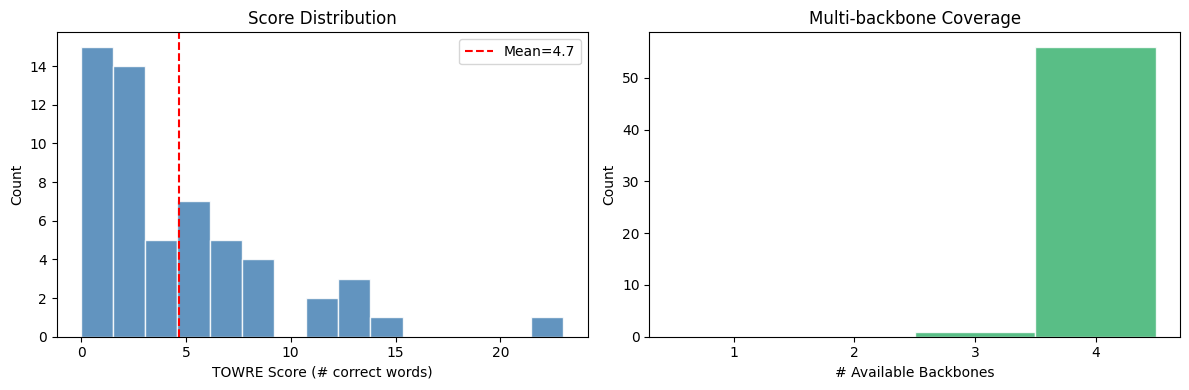


Samples         : 57
Score min/max   : 0 / 23
Score mean+/-std: 4.7 +/- 4.5
Median          : 3.0
Zero-score      : 8 (14%)

Pre-computing FastText embeddings ...
  Cached 227 embedding matrices  (avg 47 tokens,  12.8 MB total)


In [7]:
# Set global random seeds for reproducibility
torch.manual_seed(CFG_TRAIN['random_seed'])
np.random.seed(CFG_TRAIN['random_seed'])
random.seed(CFG_TRAIN['random_seed'])

# Load all samples
samples = load_dataset()

if len(samples) == 0:
    raise RuntimeError(
        "No samples loaded!\n"
        "Check that CACHE_ROOT points to the transcripts_cache directory\n"
        "and that SCORES_XLSX points to the t1_towre.xlsx file.\n"
        "JSON file stems must match the subjCode column in the xlsx exactly."
    )

scores = np.array([s.score for s in samples])

# Plot score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(scores), color='red', ls='--',
                label=f'Mean={np.mean(scores):.1f}')
axes[0].set_xlabel('TOWRE Score (# correct words)')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()

bb_counts = [len(s.transcripts) for s in samples]
axes[1].hist(bb_counts,
             bins=range(1, len(ASR_BACKBONES) + 2),
             color='mediumseagreen', edgecolor='white', alpha=0.85, align='left')
axes[1].set_xlabel('# Available Backbones')
axes[1].set_ylabel('Count')
axes[1].set_title('Multi-backbone Coverage')
axes[1].set_xticks(range(1, len(ASR_BACKBONES) + 1))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSamples         : {len(samples)}")
print(f"Score min/max   : {scores.min():.0f} / {scores.max():.0f}")
print(f"Score mean+/-std: {scores.mean():.1f} +/- {scores.std():.1f}")
print(f"Median          : {np.median(scores):.1f}")
print(f"Zero-score      : {(scores == 0).sum()} ({100*(scores==0).mean():.0f}%)")

# ★ ─────────────────────────────────────────────────────────────────────────
# ★  PRE-COMPUTE FASTTEXT EMBEDDINGS
# ★
# ★  FastText is a C++ library with a Python wrapper — it runs on CPU only
# ★  and cannot be parallelised across DataLoader workers.  Computing embeddings
# ★  inside __getitem__ means re-calling FastText on every sample every epoch.
# ★  We compute each (subject, backbone) embedding matrix ONCE here and store
# ★  it in _EMB_CACHE.  _TOK_CACHE stores the (capped) token lists so that
# ★  _augment_emb() can determine RA-filler boundaries without re-tokenising.
# ★
# ★  Memory cost: ~84 subjects × 4 backbones × 200 avg-tokens × 300-d × 4 bytes
# ★              ≈ 80 MB — negligible on T4.
# ★ ─────────────────────────────────────────────────────────────────────────
print("\nPre-computing FastText embeddings ...")
_EMB_CACHE: Dict[tuple, torch.Tensor] = {}  # (subj_code, backbone) → [T, 300]
_TOK_CACHE: Dict[tuple, List[str]]    = {}  # (subj_code, backbone) → token list

_mt = CFG_TRAIN['max_tokens']
for _s in samples:
    for _backbone, _tx in _s.transcripts.items():
        _key  = (_s.subj_code, _backbone)
        _toks = tokenize(_tx)[:_mt - 1]      # cap to match encode_tokens
        _TOK_CACHE[_key] = _toks
        _EMB_CACHE[_key] = FT_EMBEDDER.encode_tokens(_toks, _mt)

_n_mat  = len(_EMB_CACHE)
_avg_T  = sum(v.shape[0] for v in _EMB_CACHE.values()) / max(1, _n_mat)
_mem_mb = sum(v.numel() * 4 for v in _EMB_CACHE.values()) / 1e6
print(f"  Cached {_n_mat} embedding matrices  "
      f"(avg {_avg_T:.0f} tokens,  {_mem_mb:.1f} MB total)")
del _s, _backbone, _tx, _key, _toks, _n_mat, _avg_T, _mem_mb


In [8]:
# Build vocabulary from all training transcripts + TOWRE words
print("Building vocabulary...")
all_token_seqs: List[List[str]] = []

for s in samples:
    for tx in s.transcripts.values():
        all_token_seqs.append(tokenize(tx))

# Seed vocabulary with all 108 TOWRE words so they are never <unk>
for w in TOWRE_WORDS:
    all_token_seqs.append(tokenize(w))

vocab = Vocabulary(min_freq=1)
vocab.build(all_token_seqs)
vocab.save(OUTPUT_DIR / 'vocab.json')
print(f"Vocab saved -> {OUTPUT_DIR / 'vocab.json'}")

# Token-length statistics
tok_lengths = [len(tokenize(s.pick_transcript())) for s in samples]
print(f"\nTokens per transcript:  "
      f"min={min(tok_lengths)}  "
      f"median={int(np.median(tok_lengths))}  "
      f"max={max(tok_lengths)}  "
      f"mean={np.mean(tok_lengths):.1f}")
n_trunc = sum(l > CFG_TRAIN['max_tokens'] for l in tok_lengths)
print(f"(max_tokens cap = {CFG_TRAIN['max_tokens']}; "
      f"{n_trunc} transcripts will be truncated)")

# Show a sample
print(f"\nExample sample  : {samples[0]}")
_tx  = samples[0].pick_transcript()
_tok = tokenize(_tx)
print(f"Transcript (100c): {_tx[:100]}{'...' if len(_tx) > 100 else ''}")
print(f"First 20 tokens  : {_tok[:20]}")
_emb = FT_EMBEDDER.encode_tokens(_tok, CFG_TRAIN['max_tokens'])
print(f"Embed shape      : {_emb.shape}  (T incl. CLS, D={FT_EMBEDDER.dim})")
print(f"CLS row norm     : {_emb[0].norm():.4f}  (should be 0)")
if len(_tok) >= 2:
    print(f"Token[1] '{_tok[0]}' norm: {_emb[1].norm():.4f}")


Building vocabulary...
Vocabulary: 640 tokens  (min_freq=1)
Vocab saved -> /kaggle/working/outputs/vocab.json

Tokens per transcript:  min=0  median=39  max=8189  mean=250.3
(max_tokens cap = 1000; 2 transcripts will be truncated)

Example sample  : Sample(SAS_F_01 | score=11 | backbones=3)
Transcript (100c): Sampai jumpa di video selanjutnya. Terima kasih telah menonton!
First 20 tokens  : ['sampai', 'jumpa', 'di', 'video', 'selanjutnya', 'terima', 'kasih', 'telah', 'menonton']
Embed shape      : torch.Size([10, 300])  (T incl. CLS, D=300)
CLS row norm     : 0.0000  (should be 0)
Token[1] 'sampai' norm: 1.2313


## Section 7 — K-Fold Cross-Validation Training

In [9]:
n_folds = CFG_TRAIN['n_folds']
if len(samples) < n_folds:
    raise RuntimeError(f"Need at least {n_folds} samples, "
                       f"only {len(samples)} loaded.")

kf = KFold(n_splits=n_folds, shuffle=True,
           random_state=CFG_TRAIN['random_seed'])

all_fold_metrics: List[Dict[str, float]] = []
all_fold_logs   : List[Tuple[int, List[Dict]]] = []

# Out-of-fold arrays for aggregate evaluation after all folds finish
oof_preds   = np.full(len(samples), np.nan)
oof_targets = np.array([s.score for s in samples])

for fold_idx, (tr_idx, va_idx) in enumerate(
        kf.split(np.arange(len(samples))), 1):
    tr_samples = [samples[i] for i in tr_idx]
    va_samples = [samples[i] for i in va_idx]

    best_m, logs = train_one_fold(
        fold_idx, tr_samples, va_samples, vocab,
        epochs=CFG_TRAIN['epochs'], device=DEVICE,
    )
    best_m['fold'] = fold_idx
    all_fold_metrics.append(best_m)
    all_fold_logs.append((fold_idx, logs))

    # Collect OOF predictions using the saved best checkpoint
    ckpt  = torch.load(CHECKPOINT_DIR / f'fold_{fold_idx}.pt',
                       map_location=DEVICE, weights_only=True)
    oof_m = build_model().to(DEVICE).eval()
    oof_m.load_state_dict(ckpt['model_state'])
    va_dl = DataLoader(
        TOWREDataset(va_samples, augment=False),
        batch_size=CFG_TRAIN['batch_size'], collate_fn=collate_fn,
    )
    fold_preds: List[float] = []
    with torch.no_grad():
        for batch in va_dl:
            p = oof_m(batch['embeddings'].to(DEVICE),
                      batch['pad_mask'].to(DEVICE))
            fold_preds.extend(p.cpu().numpy().tolist())
    for i, pred in zip(va_idx, fold_preds):
        oof_preds[i] = pred * SCORE_NORM  # de-normalise back to raw word count
    del oof_m

# Cross-validation summary
print('\n' + '='*62)
print('  CROSS-VALIDATION SUMMARY')
print('='*62)
metric_keys = ['mae', 'rmse', 'mape', 'pearson', 'within_2']
for k in metric_keys:
    vals = [m[k] for m in all_fold_metrics
            if k in m and not (isinstance(m[k], float) and np.isnan(m[k]))]
    if vals:
        print(f"  {k:<12}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

# Overall OOF metrics (more reliable than per-fold average)
valid   = ~np.isnan(oof_preds)
oof_m_  = compute_metrics(oof_preds[valid].tolist(),
                          oof_targets[valid].tolist())
print(f"\n  OOF overall  : {fmt(oof_m_)}")

cv_df = pd.DataFrame(all_fold_metrics)
cv_df.to_csv(OUTPUT_DIR / 'cv_summary.csv', index=False)
print(f"\nCV summary saved -> {OUTPUT_DIR / 'cv_summary.csv'}")



  Fold 1  |  train=45  val=12  |  params=385,793  |  GPUs=2


/tmp/ipykernel_23/3911827446.py:93: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))
/tmp/ipykernel_23/3911827446.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):
/tmp/ipykernel_23/3911827446.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


  ep   1/1000  train=0.029  val=0.014  MAE=4.18  MAPE=71.3%  RMSE=5.12  r=0.143  +-2=33.3%  lr=1.0e-04
  ep  10/1000  train=0.010  val=0.013  MAE=4.15  MAPE=72.0%  RMSE=5.07  r=0.368  +-2=33.3%  lr=1.0e-03
  ep  20/1000  train=0.010  val=0.011  MAE=3.54  MAPE=63.8%  RMSE=4.54  r=0.161  +-2=25.0%  lr=1.0e-03
  ep  30/1000  train=0.009  val=0.009  MAE=2.99  MAPE=63.0%  RMSE=3.92  r=0.310  +-2=33.3%  lr=1.0e-03
  ep  40/1000  train=0.007  val=0.010  MAE=3.25  MAPE=63.3%  RMSE=3.93  r=0.367  +-2=33.3%  lr=1.0e-03
  ep  50/1000  train=0.007  val=0.008  MAE=3.08  MAPE=67.1%  RMSE=3.68  r=0.393  +-2=33.3%  lr=1.0e-03
  ep  60/1000  train=0.006  val=0.009  MAE=3.07  MAPE=64.4%  RMSE=3.93  r=0.327  +-2=33.3%  lr=9.9e-04
  ep  70/1000  train=0.005  val=0.011  MAE=3.75  MAPE=68.1%  RMSE=4.64  r=0.175  +-2=25.0%  lr=9.9e-04
  ep  80/1000  train=0.005  val=0.010  MAE=3.41  MAPE=67.1%  RMSE=4.22  r=0.247  +-2=41.7%  lr=9.9e-04
  ep  90/1000  train=0.006  val=0.011  MAE=3.58  MAPE=71.0%  RMSE=4.33  r

## Section 8 — Results & Visualisation

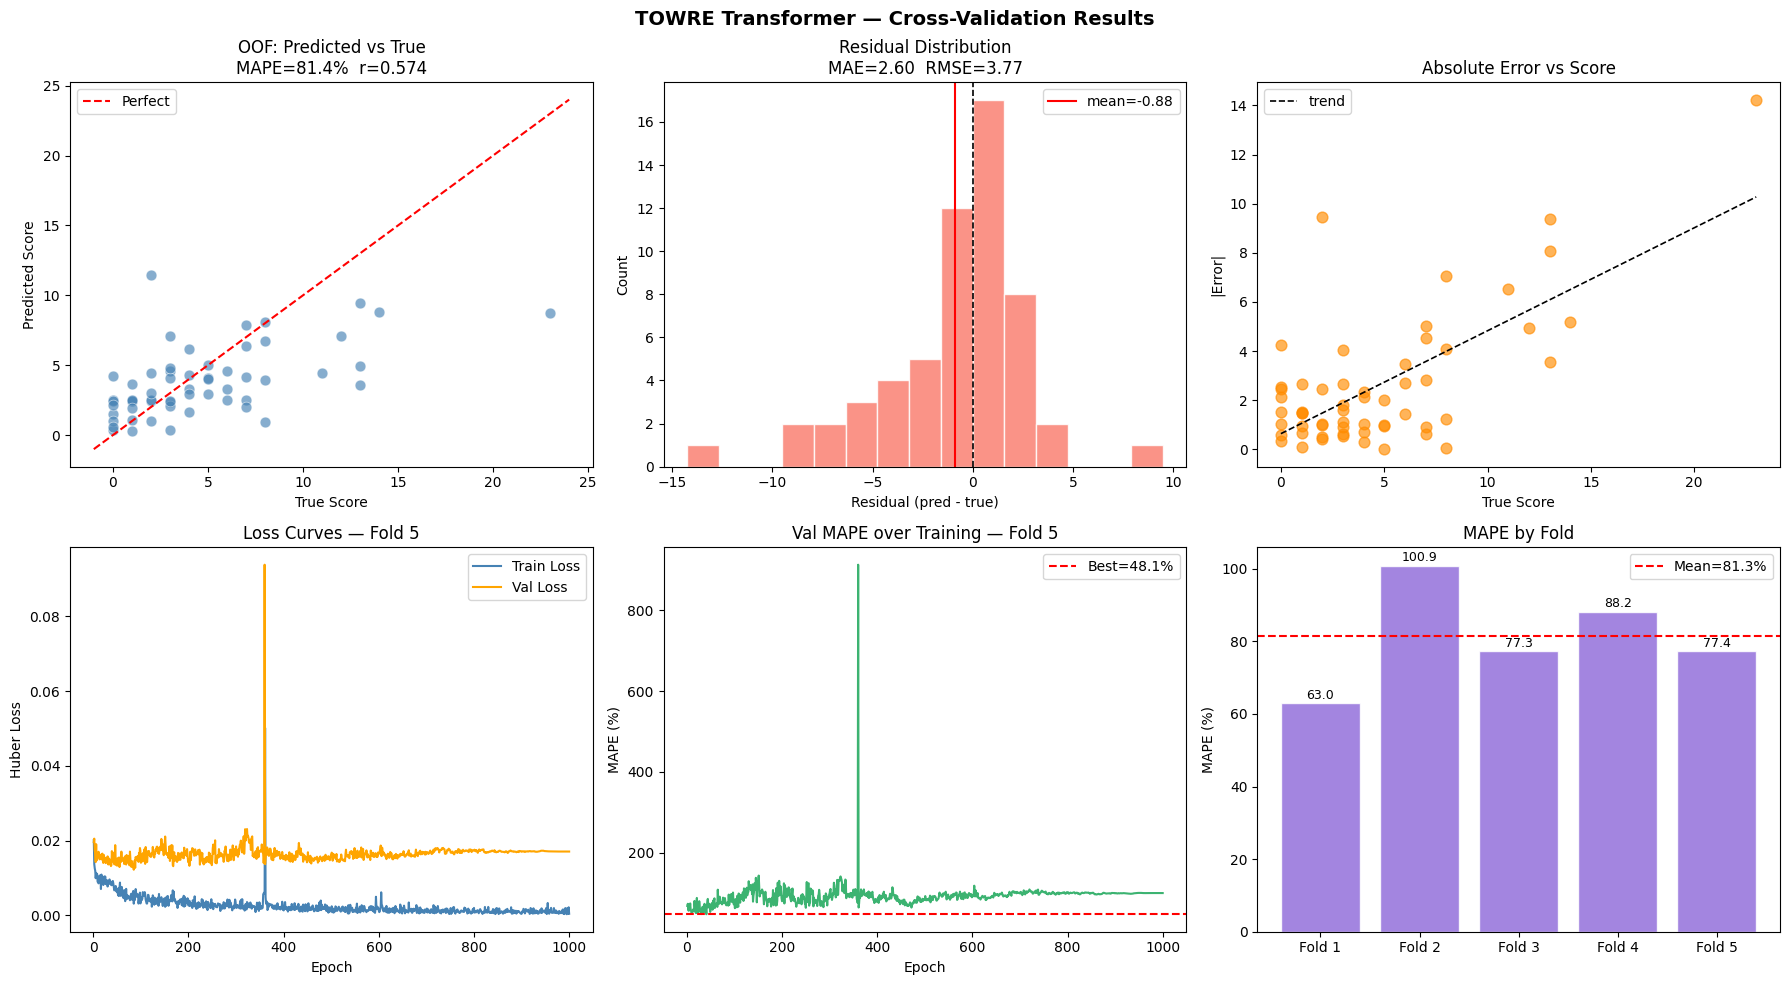

Saved -> /kaggle/working/outputs/results.png
Saved -> /kaggle/working/outputs/oof_predictions.csv


,true_score,predicted_score,residual,abs_error
count,57.00,57.00,57.00,57.00
mean,4.68,3.80,-0.88,2.60
std,4.51,2.49,3.69,2.75
min,0.00,0.32,-14.24,0.01
25%,1.00,2.39,-2.65,0.93
50%,3.00,3.31,-0.54,1.53
75%,7.00,4.60,1.47,3.49
max,23.00,11.48,9.48,14.24


In [10]:
valid_mask = ~np.isnan(oof_preds)
oof_p  = oof_preds[valid_mask]
oof_t  = oof_targets[valid_mask]
oof_m_ = compute_metrics(oof_p.tolist(), oof_t.tolist())
resid  = oof_p - oof_t

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('TOWRE Transformer — Cross-Validation Results',
             fontsize=14, fontweight='bold')

# 1) OOF scatter: predicted vs true
ax = axes[0, 0]
ax.scatter(oof_t, oof_p, alpha=0.65, s=60,
           color='steelblue', edgecolors='white', lw=0.5)
lim = [min(oof_t.min(), oof_p.min()) - 1,
       max(oof_t.max(), oof_p.max()) + 1]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('True Score'); ax.set_ylabel('Predicted Score')
ax.set_title(f'OOF: Predicted vs True\n'
             f'MAPE={oof_m_["mape"]:.1f}%  r={oof_m_["pearson"]:.3f}')
ax.legend()

# 2) Residuals histogram
ax = axes[0, 1]
ax.hist(resid, bins=15, color='salmon', edgecolor='white', alpha=0.85)
ax.axvline(0, color='k', ls='--', lw=1.2)
ax.axvline(resid.mean(), color='red', lw=1.5,
           label=f'mean={resid.mean():.2f}')
ax.set_xlabel('Residual (pred - true)'); ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution\n'
             f'MAE={oof_m_["mae"]:.2f}  RMSE={oof_m_["rmse"]:.2f}')
ax.legend()

# 3) |Error| vs true score (heteroscedasticity check)
ax = axes[0, 2]
ax.scatter(oof_t, np.abs(resid), alpha=0.65, s=60, color='darkorange')
ax.set_xlabel('True Score'); ax.set_ylabel('|Error|')
ax.set_title('Absolute Error vs Score')
z  = np.polyfit(oof_t, np.abs(resid), 1)
xs = np.linspace(oof_t.min(), oof_t.max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.2, label='trend')
ax.legend()

# 4) Training curves — last fold
last_fold_idx, last_logs = all_fold_logs[-1]
ep_  = [r['epoch']      for r in last_logs]
tr_  = [r['train_loss'] for r in last_logs]
va_  = [r['val_loss']   for r in last_logs]
mp_  = [r['mape']       for r in last_logs]
ax = axes[1, 0]
ax.plot(ep_, tr_, label='Train Loss', color='steelblue')
ax.plot(ep_, va_, label='Val Loss',   color='orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title(f'Loss Curves — Fold {last_fold_idx}')
ax.legend()

# 5) Val MAPE trajectory — last fold
ax = axes[1, 1]
ax.plot(ep_, mp_, color='mediumseagreen')
ax.axhline(min(mp_), color='red', ls='--',
           label=f'Best={min(mp_):.1f}%')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAPE (%)')
ax.set_title(f'Val MAPE over Training — Fold {last_fold_idx}')
ax.legend()

# 6) Per-fold MAPE bar chart
fold_labels = [f"Fold {m['fold']}" for m in all_fold_metrics]
fold_mapes  = [m['mape']           for m in all_fold_metrics]
ax = axes[1, 2]
bars = ax.bar(fold_labels, fold_mapes,
              color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(fold_mapes), color='red', ls='--',
           label=f'Mean={np.mean(fold_mapes):.1f}%')
ax.set_ylabel('MAPE (%)'); ax.set_title('MAPE by Fold')
ax.legend()
for bar, v in zip(bars, fold_mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {OUTPUT_DIR / 'results.png'}")

# Save OOF CSV
oof_df = pd.DataFrame({
    'subject'         : [samples[i].subj_code
                         for i in range(len(samples)) if valid_mask[i]],
    'true_score'      : oof_t,
    'predicted_score' : oof_p,
    'residual'        : resid,
    'abs_error'       : np.abs(resid),
})
oof_df.to_csv(OUTPUT_DIR / 'oof_predictions.csv', index=False)
print(f"Saved -> {OUTPUT_DIR / 'oof_predictions.csv'}")
display(oof_df.describe().round(2))


## Section 9 — Inference

Load all K fold checkpoints and use their ensemble average to predict TOWRE scores
on new transcripts.


In [11]:
def load_inference_models(
    ckpt_dir : Path,
    device   : torch.device,
) -> List[TOWRETransformer]:
    '''Load all fold checkpoints; return list of eval-mode models.'''
    models = []
    for ckpt_path in sorted(ckpt_dir.glob('fold_*.pt')):
        state = torch.load(ckpt_path, map_location=device, weights_only=True)
        m = build_model().to(device).eval()
        m.load_state_dict(state['model_state'])
        models.append(m)
    print(f"Loaded {len(models)} fold model(s) from {ckpt_dir}")
    return models


@torch.no_grad()
def predict_score(
    transcript : str,
    models     : List[TOWRETransformer],
    device     : torch.device,
) -> Dict:
    '''
    Predict TOWRE score for a single transcript string.

    Returns
    -------
    predicted_score      float  ensemble mean (possibly fractional)
    predicted_score_int  int    rounded to nearest int, >= 0
    ensemble_std         float  std across fold models (uncertainty proxy)
    fold_predictions     list   individual per-fold predictions
    n_tokens             int    word-token count of the transcript
    tokens_preview       list   first 20 tokens
    '''
    tokens = tokenize(transcript)
    embs   = FT_EMBEDDER.encode_tokens(tokens, CFG_TRAIN['max_tokens'])
    embs   = embs.unsqueeze(0).to(device)               # [1, T, ft_dim]
    T      = embs.size(1)
    mask   = torch.zeros(1, T, dtype=torch.bool, device=device)  # no padding
    preds  = [m(embs, mask).item() * SCORE_NORM for m in models]
    return dict(
        predicted_score     = round(float(np.mean(preds)), 2),
        predicted_score_int = max(0, round(float(np.mean(preds)))),
        ensemble_std        = round(float(np.std(preds)), 2),
        fold_predictions    = [round(p, 2) for p in preds],
        n_tokens            = len(tokens),
        tokens_preview      = tokens[:20],
    )


@torch.no_grad()
def predict_from_dir(
    transcript_dir : str,
    models         : List[TOWRETransformer],

    device         : torch.device,
    output_csv     : Optional[str] = None,
) -> List[Dict]:
    '''
    Predict TOWRE scores for every *.json transcript file in a directory.
    Each JSON must contain a "transcript" key.
    '''
    transcript_dir = Path(transcript_dir)
    files = sorted(transcript_dir.glob('*.json'))
    if not files:
        print(f"No JSON files in {transcript_dir}"); return []

    rows = []
    print(f"{'Subject':<25} {'Score':>7}  {'Std':>5}  Tokens")
    print('-' * 55)
    for jf in files:
        try:
            tx = (json.loads(jf.read_text(encoding='utf-8'))
                  .get('transcript') or '').strip()
        except Exception:
            tx = ''
        if not tx:
            print(f"  {jf.stem:<23}  (empty transcript)")
            rows.append({'subject': jf.stem, 'predicted_score': None,
                         'predicted_score_int': None, 'ensemble_std': None,
                         'n_tokens': 0})
            continue
        r = predict_score(tx, models, device)
        print(f"  {jf.stem:<23}  {r['predicted_score']:>6.1f}  "
              f"+/-{r['ensemble_std']:>4.1f}  ({r['n_tokens']} tokens)")
        rows.append({'subject'           : jf.stem,
                     'predicted_score'   : r['predicted_score'],
                     'predicted_score_int': r['predicted_score_int'],
                     'ensemble_std'      : r['ensemble_std'],
                     'n_tokens'          : r['n_tokens']})
    if output_csv and rows:
        out = Path(output_csv)
        out.parent.mkdir(exist_ok=True, parents=True)
        with out.open('w', newline='') as fh:
            w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
            w.writeheader(); w.writerows(rows)
        print(f"\nSaved {len(rows)} rows -> {output_csv}")
    return rows


# Load ensemble
print("Loading inference ensemble...")
inference_models = load_inference_models(CHECKPOINT_DIR, DEVICE)

# Single transcript example
_ex = "is up cat red me to no we he the and yes of him book was help then time"
_r  = predict_score(_ex, inference_models, DEVICE)
print(f"\nExample transcript : '{_ex}'")
print(f"Predicted score    : {_r['predicted_score']}  "
      f"(rounded: {_r['predicted_score_int']},  "
      f"std: +/-{_r['ensemble_std']})")
print(f"Fold predictions   : {_r['fold_predictions']}")
print(f"Tokens (first 10)  : {_r['tokens_preview'][:10]}")

# Directory inference — uncomment and set path:
# rows = predict_from_dir(
#     transcript_dir = '/kaggle/input/YOUR_TEST_TRANSCRIPTS/',
#     models         = inference_models,

#     device         = DEVICE,
#     output_csv     = str(OUTPUT_DIR / 'predictions.csv'),
# )


Loading inference ensemble...
Loaded 5 fold model(s) from /kaggle/working/outputs/checkpoints

Example transcript : 'is up cat red me to no we he the and yes of him book was help then time'
Predicted score    : 12.1  (rounded: 12,  std: +/-6.64)
Fold predictions   : [7.28, 3.42, 22.18, 16.47, 11.17]
Tokens (first 10)  : ['is', 'up', 'cat', 'red', 'me', 'to', 'no', 'we', 'he', 'the']


## Appendix — Coverage Check

Run this cell to see which subjects from the xlsx have transcripts and which don't.
Useful for diagnosing path issues before training.


In [12]:
def check_coverage(verbose: bool = True) -> pd.DataFrame:
    '''Show which xlsx subjects have transcript JSON files and which are missing.'''
    score_map = load_scores_xlsx(SCORES_XLSX)
    # Collect all subject codes found in the transcript cache
    found: Dict[str, List[str]] = {}  # subjCode -> list of backbones seen
    for folder in FOLDERS:
        for backbone in ASR_BACKBONES:
            d = discover_transcripts(CACHE_ROOT, folder, backbone)
            for code in d:
                found.setdefault(code, []).append(f'{folder}/{backbone}')

    rows = []
    for code, score in sorted(score_map.items()):
        backbones = found.get(code, [])
        rows.append({
            'subjCode'   : code,
            'xlsx_score' : int(score),
            'n_backbones': len(backbones),
            'has_tx'     : len(backbones) > 0,
            'backbones'  : ', '.join(backbones) if backbones else '—',
        })

    df = pd.DataFrame(rows)
    n_ok   = df['has_tx'].sum()
    n_miss = (~df['has_tx']).sum()
    print(f"Subjects in xlsx : {len(df)}")
    print(f"  Have transcripts : {n_ok}")
    print(f"  No transcript    : {n_miss}")
    if verbose and n_miss > 0:
        print("\nMissing transcripts (likely did_main_block=no):")
        for _, r in df[~df['has_tx']].iterrows():
            print(f"  {r['subjCode']}  score={r['xlsx_score']}")
    return df

coverage_df = check_coverage()
display(coverage_df)


Subjects in xlsx : 84
  Have transcripts : 57
  No transcript    : 27

Missing transcripts (likely did_main_block=no):
  SAS_F_08  score=0
  SAS_F_09  score=0
  SAS_F_11  score=0
  SAS_F_15  score=0
  SAS_F_19  score=0
  SAS_F_23  score=0
  SAS_F_25  score=0
  SAS_F_31  score=0
  SAS_F_36  score=0
  SAS_M_13  score=0
  SAS_M_17  score=0
  SAS_M_18  score=0
  SAS_M_20  score=0
  SAS_M_22  score=0
  SAS_M_35  score=0
  SFS_F_48  score=0
  SFS_F_57  score=0
  SFS_F_62  score=0
  SFS_F_68  score=0
  SFS_F_69  score=0
  SFS_F_79  score=0
  SFS_M_54  score=0
  SFS_M_55  score=0
  SFS_M_64  score=0
  SFS_M_73  score=0
  SFS_M_82  score=0
  SFS_M_86  score=0


,subjCode,xlsx_score,n_backbones,has_tx,backbones
0,SAS_F_01,11,4,True,"t1/qwen-ASR-1.7B, t1/groq__whisper-large-v3, t..."
1,SAS_F_02,8,4,True,"t1/qwen-ASR-1.7B, t1/groq__whisper-large-v3, t..."
2,SAS_F_04,14,4,True,"t1/qwen-ASR-1.7B, t1/groq__whisper-large-v3, t..."
3,SAS_F_08,0,0,False,—
4,SAS_F_09,0,0,False,—
...,...,...,...,...,...
79,SFS_M_75,1,4,True,"t1/qwen-ASR-1.7B, t1/groq__whisper-large-v3, t..."
80,SFS_M_78,4,4,True,"t1/qwen-ASR-1.7B, t1/groq__whisper-large-v3, t..."
81,SFS_M_80,4,4,True,"t1/qwen-ASR-1.7B, t1/groq__whisper-large-v3, t..."
82,SFS_M_82,0,0,False,—
